# Figure 4 Replication: Cross-Task Generalization Matrices & Heatmaps

This notebook replicates **Figure 4** from *Testing the Limits of Truth Directions in LLMs* (Poulis et al., 2024) on **DeepSeek-R1-Distill-8B**.

It generates $9 \times 9$ cross-task AUROC generalization matrices across all 9 complexity tasks ($A_1-A_3, F_0-F_5$) comparing:
- **Plaintext (No-Prompt Baseline)**
- **Chain-of-Thought (CoT Zero-Shot)**
- **$\Delta$ Transfer Gain (CoT - Plaintext)**

Evaluated at **Layer 25** (Canonical Paper Benchmark) and **Layer 30** (Late-Stage Convergence).

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "results_database.csv"
df = pd.read_csv(csv_path)
task_order = ["A1", "A2", "A3", "F0", "F1", "F2", "F3", "F4", "F5"]
model_name = "deepseek-r1-distill-8b"
os.makedirs("figures", exist_ok=True)

print(f"Loaded {len(df)} rows from {csv_path}")
print("Conditions available:", df["train_condition"].unique())

def build_matrix(df, model, condition, layer, tasks):
    n = len(tasks)
    mat = np.full((n, n), np.nan)
    sub = df[(df["model"] == model) & (df["train_condition"] == condition) & (df["test_condition"] == condition) & (df["layer"] == layer)]
    for i, tr in enumerate(tasks):
        for j, te in enumerate(tasks):
            r = sub[(sub["train_task"] == tr) & (sub["test_task"] == te)]
            if len(r) > 0:
                mat[i, j] = float(r.iloc[0]["auroc"])
    return mat


Loaded 5346 rows from results_database.csv
Conditions available: <StringArray>
['no-prompt', 'cot-zero-shot']
Length: 2, dtype: str


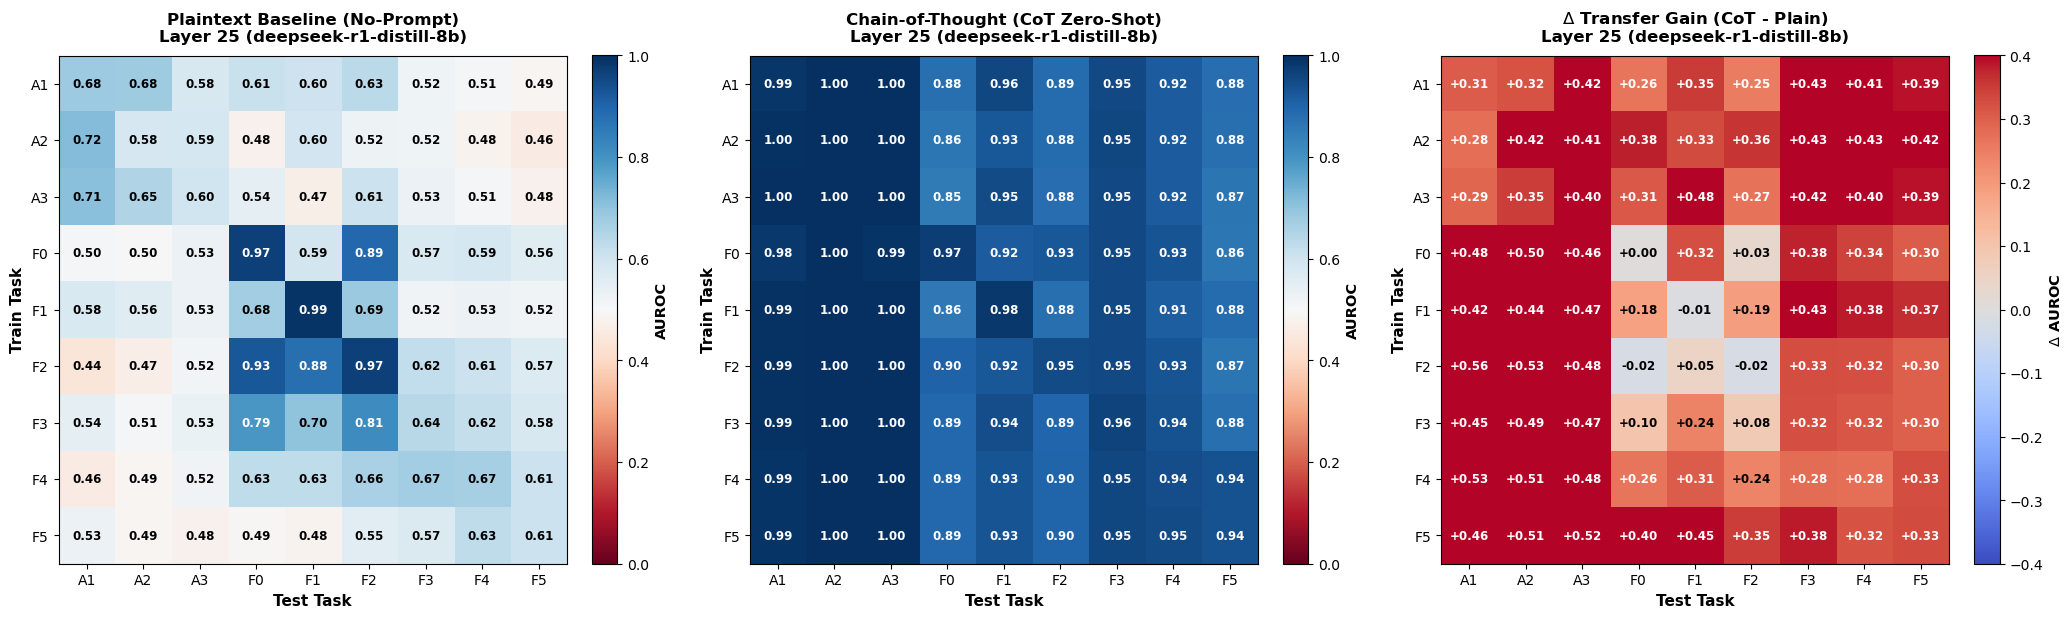

In [5]:
# Plot Layer 25 (Canonical Paper Parity Depth)
layer = 25
plain_25 = build_matrix(df, model_name, "no-prompt", layer, task_order)
cot_25 = build_matrix(df, model_name, "cot-zero-shot", layer, task_order)
diff_25 = cot_25 - plain_25

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
n = len(task_order)
panels = [
    ("Plaintext Baseline (No-Prompt)", plain_25, "RdBu", 0.0, 1.0, "AUROC"),
    ("Chain-of-Thought (CoT Zero-Shot)", cot_25, "RdBu", 0.0, 1.0, "AUROC"),
    (r"$\Delta$ Transfer Gain (CoT - Plain)", diff_25, "coolwarm", -0.4, 0.4, r"$\Delta$ AUROC")
]

for ax, (title, mat, cmap, vmin, vmax, cbar_lbl) in zip(axes, panels):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            if not np.isnan(val):
                txt_color = "white" if ((val < 0.35 or val > 0.75) if cmap == "RdBu" else (abs(val) > 0.25)) else "black"
                txt = f"{val:.2f}" if cmap == "RdBu" else f"{val:+.2f}"
                ax.text(j, i, txt, ha="center", va="center", color=txt_color, fontsize=8.5, fontweight="bold")
    cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.04)
    cbar.set_label(cbar_lbl, fontsize=10.5, fontweight="semibold")
    ax.set_xticks(range(n))
    ax.set_xticklabels(task_order, fontsize=10, fontweight="medium")
    ax.set_yticks(range(n))
    ax.set_yticklabels(task_order, fontsize=10, fontweight="medium")
    ax.set_xlabel("Test Task", fontsize=11, fontweight="semibold")
    ax.set_ylabel("Train Task", fontsize=11, fontweight="semibold")
    ax.set_title(f"{title}\nLayer {layer} ({model_name})", fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("figures/figure_4_cross_task_deepseek_l25.png", dpi=200, bbox_inches="tight")
plt.show()


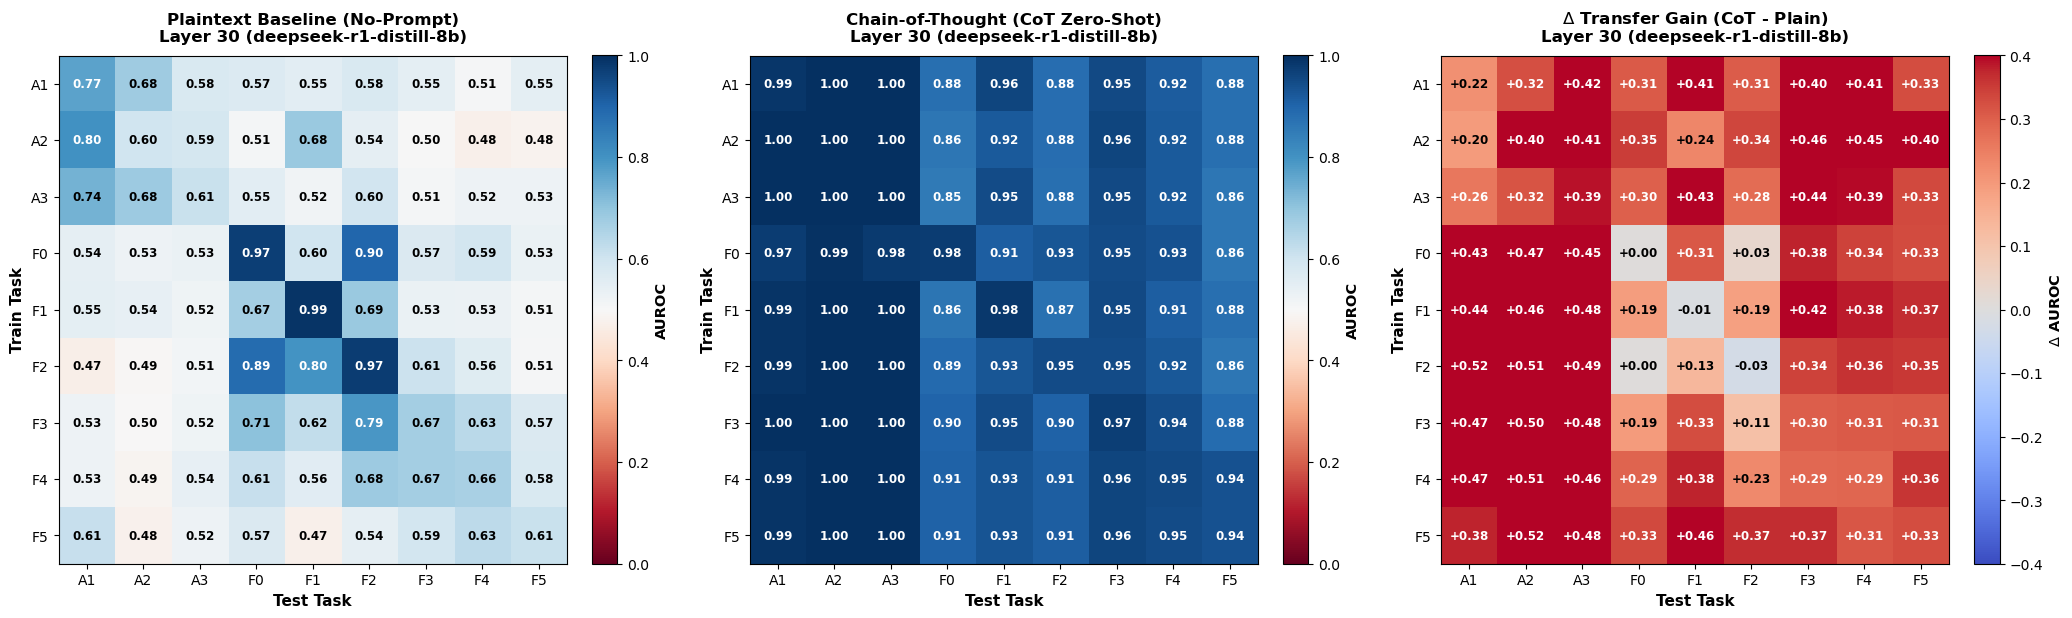

In [6]:
# Plot Layer 30 (Late-Stage Reasoning Depth)
layer = 30
plain_30 = build_matrix(df, model_name, "no-prompt", layer, task_order)
cot_30 = build_matrix(df, model_name, "cot-zero-shot", layer, task_order)
diff_30 = cot_30 - plain_30

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
panels = [
    ("Plaintext Baseline (No-Prompt)", plain_30, "RdBu", 0.0, 1.0, "AUROC"),
    ("Chain-of-Thought (CoT Zero-Shot)", cot_30, "RdBu", 0.0, 1.0, "AUROC"),
    (r"$\Delta$ Transfer Gain (CoT - Plain)", diff_30, "coolwarm", -0.4, 0.4, r"$\Delta$ AUROC")
]

for ax, (title, mat, cmap, vmin, vmax, cbar_lbl) in zip(axes, panels):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            if not np.isnan(val):
                txt_color = "white" if ((val < 0.35 or val > 0.75) if cmap == "RdBu" else (abs(val) > 0.25)) else "black"
                txt = f"{val:.2f}" if cmap == "RdBu" else f"{val:+.2f}"
                ax.text(j, i, txt, ha="center", va="center", color=txt_color, fontsize=8.5, fontweight="bold")
    cbar = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.04)
    cbar.set_label(cbar_lbl, fontsize=10.5, fontweight="semibold")
    ax.set_xticks(range(n))
    ax.set_xticklabels(task_order, fontsize=10, fontweight="medium")
    ax.set_yticks(range(n))
    ax.set_yticklabels(task_order, fontsize=10, fontweight="medium")
    ax.set_xlabel("Test Task", fontsize=11, fontweight="semibold")
    ax.set_ylabel("Train Task", fontsize=11, fontweight="semibold")
    ax.set_title(f"{title}\nLayer {layer} ({model_name})", fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("figures/figure_4_cross_task_deepseek_l30.png", dpi=200, bbox_inches="tight")
plt.show()
